# Bessel Envelope Extrema Identification

Identify the 4 maxima and 4 minima of the Bessel (jinc) envelope in the fringe data across representative frequency channels.

1. Load data and apply DC / chip-gain corrections (same pipeline as nb 05).
2. Interpolate $|V|$ onto a uniform HA grid and smooth.
3. Use `find_peaks` to locate 4 minima and 4 maxima by prominence.
4. Derive a prior $R$ from extrema positions, then fit the full jinc envelope.

In [1]:
from __future__ import annotations

import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

sys.path.insert(0, str(Path("..").resolve()))
from utils import (
    F_S_HZ, N_FFT, F_RF0_HZ, PLOT_BAND_GHZ,
    C_LIGHT_MS, OMEGA_EARTH_RAD_S, SIDEREAL_DAY_S,
    NCH_LAT_DEG, NCH_LON_DEG,
    NOMINAL_B_EW_M, NOMINAL_B_NS_M, BAD_CHANNELS,
    SOLAR_DIAMETER_ARCMIN_NOMINAL,
    load_processed_sun_chip_series,
    sky_baseline_lambda,
    adaptive_real_dc_correction,
    apply_chip_gain_correction, CHIP_GAIN_RATIOS_DEFAULT,
    TEXTWIDTH_IN, LABEL_SIZE, TICK_SIZE, LEGEND_SIZE,
    SS_FINE, LW_LIGHT, LW_STANDARD, MS_FINE,
)

%matplotlib inline
plt.rcParams.update({"figure.dpi": 130, "figure.facecolor": "white"})
print("Imports OK.")

Imports OK.


## 1. Load data

In [2]:
# ── Load chip data ──────────────────────────────────────────────────
DATA_DIR = Path("../../../data/lab03/sun_calibration/chips")
chip_paths = sorted(DATA_DIR.glob("sun_calibration_chip_*.npz"))
print(f"Found {len(chip_paths)} chip files:")
for p in chip_paths:
    print(f"  {p.name}")

chip_data = load_processed_sun_chip_series(chip_paths)

# ── Unpack ──────────────────────────────────────────────────────────
captures    = chip_data.captures
corr_raw    = captures.corr
corr_std    = captures.corr_std
F_SKY_GHZ   = chip_data.f_sky_ghz
F_SKY_HZ    = F_SKY_GHZ * 1e9
DF_HZ       = chip_data.df_hz
unix_mid    = captures.unix_mid
ha_deg_arr  = chip_data.ha_deg
ha_rad_arr  = np.deg2rad(ha_deg_arr)
sun_dec     = chip_data.sun_dec_deg
dec_rad_mean = np.deg2rad(np.nanmean(sun_dec))
dec_rad_arr  = np.deg2rad(sun_dec)
chip_slices  = chip_data.chip_slices
N_chips      = len(chip_slices)

band_mask      = (F_SKY_GHZ >= PLOT_BAND_GHZ[0]) & (F_SKY_GHZ <= PLOT_BAND_GHZ[1])
band_center_hz = np.mean(F_SKY_HZ[band_mask])

print(f"Captures: {len(unix_mid)}, Channels: {len(F_SKY_GHZ)}")
print(f"Analysis band: {PLOT_BAND_GHZ[0]:.3f}–{PLOT_BAND_GHZ[1]:.3f} GHz ({band_mask.sum()} ch)")
print(f"HA range: {ha_deg_arr.min():.1f} to {ha_deg_arr.max():.1f} deg")

Found 3 chip files:
  sun_calibration_chip_00.npz
  sun_calibration_chip_01.npz
  sun_calibration_chip_02.npz
Captures: 8226, Channels: 1024
Analysis band: 10.415–10.485 GHz (287 ch)
HA range: -79.9 to 22.0 deg


In [3]:
# ── DC correction ───────────────────────────────────────────────────
DC_N_PERIODS       = 3.0
DC_MIN_WINDOW_CAPS = 7
DC_MAX_WINDOW_CAPS = 201

dc_result = adaptive_real_dc_correction(
    corr_chips=[corr_raw[sl] for sl in chip_slices],
    unix_chips=[unix_mid[sl] for sl in chip_slices],
    ha_rad_chips=[ha_rad_arr[sl] for sl in chip_slices],
    bad_channels=BAD_CHANNELS,
    b_ew=NOMINAL_B_EW_M,
    freq_hz=band_center_hz,
    dec_rad=dec_rad_mean,
    n_periods=DC_N_PERIODS,
    min_window_caps=DC_MIN_WINDOW_CAPS,
    max_window_caps=DC_MAX_WINDOW_CAPS,
)
corr_dc = dc_result.corr_dc

# ── Chip-gain correction ───────────────────────────────────────────
import pickle as _pkl

_sidecar = Path("_chip_gain_measured.pkl")
if _sidecar.exists():
    with open(_sidecar, "rb") as _f:
        _cal = _pkl.load(_f)
    chip_gains = np.array(_cal["chip_gains_measured"])
    print(f"Loaded chip gains: {chip_gains}")
else:
    chip_gains = np.array(CHIP_GAIN_RATIOS_DEFAULT[:N_chips])
    print(f"[warning] using default chip gains: {chip_gains}")

corr_dc = apply_chip_gain_correction(corr_dc, chip_slices, chip_gains)

# ── DC-correction alpha ────────────────────────────────────────────
_dc_sidecar = Path("_dc_correction_alpha.pkl")
if _dc_sidecar.exists():
    with open(_dc_sidecar, "rb") as _f:
        DC_ALPHA = float(_pkl.load(_f)["alpha"])
    if abs(DC_ALPHA - 1.0) > 1e-6:
        corr_dc = corr_dc / DC_ALPHA
        print(f"Applied DC alpha = {DC_ALPHA:.4f}")
else:
    print("[warning] DC alpha sidecar not found, assuming 1.0")

# ── Load adopted baseline ──────────────────────────────────────────
import pickle

with open("_baseline_adopted.pkl", "rb") as f:
    _bl = pickle.load(f)
B_EW     = _bl["b_ew_m"]
B_EW_ERR = _bl["b_ew_err_m"]
B_NS     = _bl["b_ns_m"]
B_NS_ERR = _bl["b_ns_err_m"]
print(f"Baseline: B_EW = {B_EW:.4f} m, B_NS = {B_NS:.4f} m")

# ── Good channels & representative indices ─────────────────────────
good_ch = band_mask & ~np.isin(np.arange(corr_dc.shape[1]), list(BAD_CHANNELS))
band_indices = np.where(good_ch)[0]
k_mid = band_indices[len(band_indices) // 2]
print(f"Representative channel: {k_mid} ({F_SKY_GHZ[k_mid]:.3f} GHz)")
print(f"Good channels in band: {good_ch.sum()}")

Loaded chip gains: [1.         1.01017094 1.09913281]
Applied DC alpha = 1.0598
Baseline: B_EW = 15.1148 m, B_NS = 1.4746 m
Representative channel: 655 (10.450 GHz)
Good channels in band: 285


## 2. Interpolate to uniform HA grid

Interpolate $|V|$ onto a uniform HA grid and smooth with a running mean for peak-finding.

In [4]:
# Use all good channels in the analysis band
all_ch = np.where(good_ch)[0]
print(f"{len(all_ch)} good channels in analysis band")

# Single representative channel for visualisation
k_mid = all_ch[len(all_ch) // 2]
print(f"Representative channel: ch {k_mid} ({F_SKY_GHZ[k_mid]:.3f} GHz)")

285 good channels in analysis band
Representative channel: ch 655 (10.450 GHz)


In [5]:
N_UNIFORM  = 2000    # interpolation grid size
SMOOTH_W   = 21      # running-mean smoothing kernel width

def interpolate_channel(k_ch):
    """Return (ha_uni, mf_smooth, V0, u_uni, env_raw) for channel k_ch."""
    env = np.abs(corr_dc[:, k_ch])
    u = np.abs(sky_baseline_lambda(ha_rad_arr, dec_rad_mean, B_EW, B_NS, float(F_SKY_HZ[k_ch])))

    finite = np.isfinite(ha_deg_arr) & np.isfinite(env)
    order = np.argsort(ha_deg_arr[finite])
    ha_s  = ha_deg_arr[finite][order]
    env_s = env[finite][order]
    u_s   = u[finite][order]

    ha_uni  = np.linspace(ha_s[0], ha_s[-1], N_UNIFORM)
    env_uni = np.interp(ha_uni, ha_s, env_s)
    u_uni   = np.interp(ha_uni, ha_s, u_s)

    V0 = float(np.nanmax(env_uni))
    mf = env_uni / V0

    kernel = np.ones(SMOOTH_W) / SMOOTH_W
    mf_smooth = np.convolve(mf, kernel, mode="same")

    return ha_uni, mf_smooth, V0, u_uni, env

# Process all good channels
ch_data = {}
for k in all_ch:
    ha_uni, mf_sm, V0, u_uni, env_raw = interpolate_channel(k)
    ch_data[k] = dict(ha_uni=ha_uni, mf_smooth=mf_sm, V0=V0, u_uni=u_uni, env_raw=env_raw)

print(f"Processed {len(ch_data)} channels.")

Processed 285 channels.


## 3. Find maxima and minima of the Bessel envelope

### Why not fit the jinc directly?

The uniform-disk jinc model predicts that the visibility drops to **zero** at the $J_1$ nulls. In practice, the observed $|V|$ at the nulls is significantly inflated above zero due to:

- **Sunspots** — compact bright features add a baseline visibility floor that fills in the nulls.
- **Limb brightening** — at cm wavelengths, the chromospheric temperature gradient makes the solar limb brighter than the disk centre, modifying the visibility from a pure jinc and raising the null depths.

These effects distort the envelope shape — particularly the null depths — making a direct least-squares fit of $A \cdot |2J_1(x)/x|$ unreliable: the fit would try to compromise between matching the peaks and the non-zero nulls, biasing $R$ and $A$.

Instead, we identify the **positions** of the maxima and minima in HA, which depend on $R$ but **not** on the amplitude distortion. The Bessel roots (where extrema occur in $x = 2\pi q R$) are fixed mathematical constants regardless of sunspots or limb brightening. This gives a robust $R$ estimate per frequency channel.

### Derivation

For a uniform disk of angular radius $R$, the visibility amplitude is

$$|V(q)| = V_0 \left|\frac{2\,J_1(2\pi q R)}{2\pi q R}\right|$$

where $q = \sqrt{u^2 + v_0^2}$ is the full projected baseline in wavelengths (from `sky_baseline_lambda`). This quantity is proportional to $|\cos h|$ for an EW-dominated baseline — it is **maximum near transit** and minimum far from transit.

- **Minima** (nulls) occur where $J_1(x) = 0$, i.e. $x = 2\pi q R = j_{1,n}$, so $R = j_{1,n} / (2\pi q)$.
- **Maxima** (sidelobe peaks) occur where $J_2(x) = 0$, i.e. $x = j_{2,n}$, so $R = j_{2,n} / (2\pi q)$.

Critically, sunspots and limb brightening shift the **depth** of the nulls and the **amplitude** of the sidelobes, but they do not significantly shift the **positions** of these features in $q$-space. The extremum locations are set by the zeros of $J_1$ and $J_2$, which depend only on the disk radius $R$.

### Identified features

Since $q$ increases toward transit, **low-order features appear far from transit** and **high-order features appear near transit**. The search windows are computed dynamically from the actual baseline and $D \in [32', 34']$:

| # | Feature | Type | Bessel root | Value |
|---|---------|------|-------------|-------|
| 1 | j₂,₁ | max | 1st zero of $J_2$ | 5.136 |
| 2 | j₁,₂ | min | 2nd zero of $J_1$ | 7.016 |
| 3 | j₂,₂ | max | 2nd zero of $J_2$ | 8.417 |
| 4 | j₁,₃ | min | 3rd zero of $J_1$ | 10.174 |
| 5 | j₂,₃ | max | 3rd zero of $J_2$ | 11.620 |
| 6 | j₁,₄ | min | 4th zero of $J_1$ | 13.324 |
| 7 | j₂,₄ | max | 4th zero of $J_2$ | 14.796 |

### Estimating $R$ from each feature

For any identified extremum at projected baseline $q$:

$$R = \frac{j_{n}}{2\pi\,q}$$

Each feature gives an independent $R$ estimate per frequency channel; the IVW mean across all matched features yields $R_{\mathrm{prior}}$.

In [6]:
from scipy.signal import find_peaks, peak_prominences
from scipy.special import jn_zeros

# Bessel roots
j1_roots = jn_zeros(1, 8)   # J1 zeros (minima of |V|)
j2_roots = jn_zeros(2, 8)   # J2 zeros (maxima of |V|)

# Features ordered from smallest to largest root (= farthest to nearest transit),
# because sky_baseline_lambda returns the full projected baseline q which is
# proportional to |cos(h)| — INCREASING toward transit.
FEATURES = [
    ("max", j2_roots[0], "j2,1"),  # 1st J2 zero — farthest from transit
    ("min", j1_roots[1], "j1,2"),  # 2nd J1 zero
    ("max", j2_roots[1], "j2,2"),  # 2nd J2 zero
    ("min", j1_roots[2], "j1,3"),  # 3rd J1 zero
    # ("max", j2_roots[2], "j2,3"),  # 3rd J2 zero
    # ("min", j1_roots[3], "j1,4"),  # 4th J1 zero
    # ("max", j2_roots[3], "j2,4"),  # 4th J2 zero — nearest transit
]

# Diameter range for window computation
D_LO_ARCMIN = 31.5
D_HI_ARCMIN = 34.5
MARGIN_DEG   = 1.0

R_lo = np.deg2rad(D_LO_ARCMIN / 2.0 / 60.0)
R_hi = np.deg2rad(D_HI_ARCMIN / 2.0 / 60.0)

def u_to_ha(u_target, freq_hz=band_center_hz):
    """Map a target |q| to HA (degrees, negative side) using actual baseline.

    Sweeps HA from -90 to 0 and finds where sky_baseline_lambda = u_target.
    """
    ha_test = np.linspace(-np.pi/2, 0, 10000)
    q_test = sky_baseline_lambda(ha_test, dec_rad_mean, B_EW, B_NS, freq_hz)
    idx = np.argmin(np.abs(q_test - u_target))
    return np.rad2deg(ha_test[idx])

# Compute windows
FEATURE_WINDOWS = []
print(f"Computing HA windows for D = [{D_LO_ARCMIN}, {D_HI_ARCMIN}] arcmin")
print(f"Baseline: B_EW = {B_EW:.4f} m, B_NS = {B_NS:.4f} m")
print(f"Dec: {np.rad2deg(dec_rad_mean):.3f} deg")
print(f"Band centre: {band_center_hz/1e9:.4f} GHz")
print()
print(f"{'Feature':>6} {'Type':>4} {'Root':>8} {'q D=lo':>10} {'q D=hi':>10} "
      f"{'HA D=lo':>9} {'HA D=hi':>9} {'Window':>16}")
print("-" * 82)

for kind, root, label in FEATURES:
    # Smaller R (D_LO) -> larger q needed -> closer to transit (less negative HA)
    # Larger R (D_HI) -> smaller q needed -> farther from transit (more negative HA)
    q_at_lo = root / (2 * np.pi * R_lo)  # larger q
    q_at_hi = root / (2 * np.pi * R_hi)  # smaller q

    ha_at_lo = u_to_ha(q_at_lo)  # less negative (closer to transit)
    ha_at_hi = u_to_ha(q_at_hi)  # more negative (farther from transit)

    # ha_at_hi is more negative, ha_at_lo is less negative
    ha_lo = ha_at_hi - MARGIN_DEG  # extend toward more negative
    ha_hi = ha_at_lo + MARGIN_DEG  # extend toward transit

    FEATURE_WINDOWS.append((ha_lo, ha_hi, kind, root, label))

    print(f"{label:>6} {kind:>4} {root:>8.3f} {q_at_lo:>10.1f} {q_at_hi:>10.1f} "
          f"{ha_at_lo:>+9.1f} {ha_at_hi:>+9.1f} "
          f"[{ha_lo:+.1f}, {ha_hi:+.1f}]")

# Check for overlaps
print()
for i in range(len(FEATURE_WINDOWS) - 1):
    gap = FEATURE_WINDOWS[i+1][0] - FEATURE_WINDOWS[i][1]
    status = "OK" if gap > 0 else "OVERLAP"
    print(f"  Gap {FEATURE_WINDOWS[i][4]} -> {FEATURE_WINDOWS[i+1][4]}: {gap:+.1f} deg  {status}")

Computing HA windows for D = [31.5, 34.5] arcmin
Baseline: B_EW = 15.1148 m, B_NS = 1.4746 m
Dec: -0.083 deg
Band centre: 10.4499 GHz

Feature Type     Root     q D=lo     q D=hi   HA D=lo   HA D=hi           Window
----------------------------------------------------------------------------------
  j2,1  max    5.136      178.4      162.9     -74.2     -76.0 [-77.0, -73.2]
  j1,2  min    7.016      243.7      222.5     -66.3     -68.9 [-69.9, -65.3]
  j2,2  max    8.417      292.4      267.0     -60.2     -63.4 [-64.4, -59.2]
  j1,3  min   10.173      353.4      322.7     -51.7     -56.1 [-57.1, -50.7]

  Gap j2,1 -> j1,2: +3.3 deg  OK
  Gap j1,2 -> j2,2: +0.9 deg  OK
  Gap j2,2 -> j1,3: +2.1 deg  OK


In [7]:
def find_extrema_in_windows(ha_uni, mf_smooth, u_uni, windows=FEATURE_WINDOWS):
    """Find the single most prominent max or min within each HA window.

    Returns a list of dicts with keys: ha, mf, u, type, root, label.
    """
    found = []
    for ha_lo, ha_hi, kind, root, label in windows:
        mask = (ha_uni >= ha_lo) & (ha_uni <= ha_hi)
        if mask.sum() < 3:
            continue
        sub_mf = mf_smooth[mask]
        sub_ha = ha_uni[mask]
        sub_u  = u_uni[mask]

        if kind == "max":
            pk, _ = find_peaks(sub_mf)
            if len(pk) == 0:
                continue
            prom = peak_prominences(sub_mf, pk)[0]
            best = pk[np.argmax(prom)]
        else:
            pk, _ = find_peaks(-sub_mf)
            if len(pk) == 0:
                continue
            prom = peak_prominences(-sub_mf, pk)[0]
            best = pk[np.argmax(prom)]

        found.append({
            "ha": sub_ha[best],
            "mf": sub_mf[best],
            "u": sub_u[best],
            "type": kind,
            "root": root,
            "label": label,
        })
    return found

# Run on ALL good channels
ch_extrema = {}
for k in all_ch:
    d = ch_data[k]
    ch_extrema[k] = find_extrema_in_windows(d["ha_uni"], d["mf_smooth"], d["u_uni"])

# Print summary for mid channel
# k_mid already set in cell 6
print(f"Found extrema for {len(ch_extrema)} channels.")
print(f"Example: ch {k_mid} ({F_SKY_GHZ[k_mid]:.3f} GHz) — {len(ch_extrema[k_mid])} features:")
for f in ch_extrema[k_mid]:
    R_est = f["root"] / (2 * np.pi * f["u"])
    D_est = np.rad2deg(2 * R_est) * 60
    print(f"  {f['label']:>5} {f['type']:>3}: HA = {f['ha']:+7.2f},  "
          f"|u| = {f['u']:.0f},  root = {f['root']:.3f},  D = {D_est:.2f}\'")

Found extrema for 285 channels.
Example: ch 655 (10.450 GHz) — 4 features:
   j2,1 max: HA =  -76.03,  |u| = 163,  root = 5.136,  D = 34.49'
   j1,2 min: HA =  -68.39,  |u| = 227,  root = 7.016,  D = 33.81'
   j2,2 max: HA =  -63.09,  |u| = 270,  root = 8.417,  D = 34.15'
   j1,3 min: HA =  -56.20,  |u| = 322,  root = 10.173,  D = 34.59'


## 4. Visualisation

Raw $|V|$ scatter vs hour angle with the identified maxima and minima overlaid (mid-band channel).

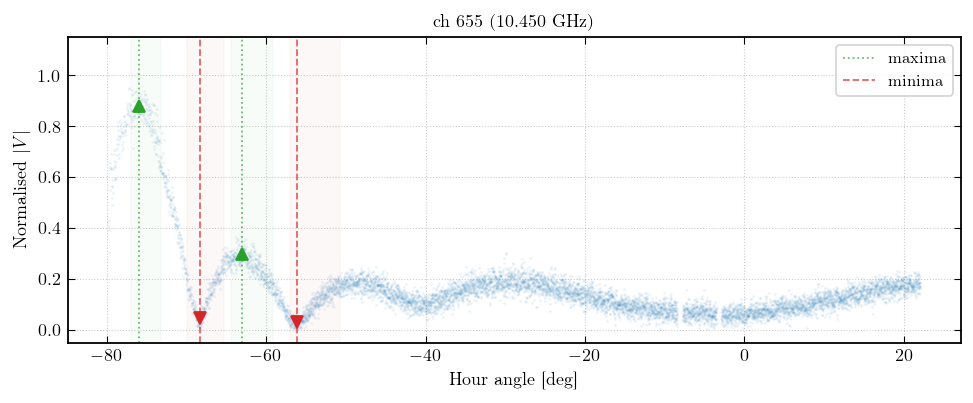

In [8]:
k_show = k_mid
d = ch_data[k_show]
features = ch_extrema[k_show]

fig, ax = plt.subplots(figsize=(TEXTWIDTH_IN, 3.2))

finite = np.isfinite(ha_deg_arr) & np.isfinite(d["env_raw"])
ax.scatter(ha_deg_arr[finite], d["env_raw"][finite] / d["V0"],
           s=0.3, alpha=0.08, color="C0", rasterized=True)

plotted_min, plotted_max = False, False
for f in features:
    if f["type"] == "min":
        ax.axvline(f["ha"], color="C3", lw=LW_LIGHT, ls="--", alpha=0.7,
                   label="minima" if not plotted_min else None)
        ax.plot(f["ha"], f["mf"], "v", ms=7, color="C3", zorder=5)
        plotted_min = True
    else:
        ax.axvline(f["ha"], color="C2", lw=LW_LIGHT, ls=":", alpha=0.7,
                   label="maxima" if not plotted_max else None)
        ax.plot(f["ha"], f["mf"], "^", ms=7, color="C2", zorder=5)
        plotted_max = True

# Show window boundaries
for ha_lo, ha_hi, kind, root, label in FEATURE_WINDOWS:
    ax.axvspan(ha_lo, ha_hi, alpha=0.03, color="C2" if kind == "max" else "C3")

ax.set_xlabel("Hour angle [deg]")
ax.set_ylabel("Normalised $|V|$")
ax.set_title(f"ch {k_show} ({F_SKY_GHZ[k_show]:.3f} GHz)", fontsize=TICK_SIZE)
ax.legend(fontsize=TICK_SIZE - 1, loc="upper right")
ax.set_ylim(-0.05, 1.15)
fig.tight_layout()
plt.show()

## 5. Prior $R$ from extrema positions

Each identified extremum gives an independent solar radius estimate: $R = j_k / (2\pi\, |u|_{\mathrm{measured}})$. Average across all matched extrema to obtain $R_{\mathrm{prior}}$ per channel.

Channels with valid R_prior: 285 / 285
IVW prior diameter: 34.317 +/- 0.022 arcmin
IVW prior radius:   17.159 arcmin


<>:38: SyntaxWarning: invalid escape sequence '\p'
<>:38: SyntaxWarning: invalid escape sequence '\p'
/tmp/ipykernel_801969/618912179.py:38: SyntaxWarning: invalid escape sequence '\p'
  label=f"IVW = {D_ivw:.2f} $\pm$ {D_ivw_err:.2f} arcmin")


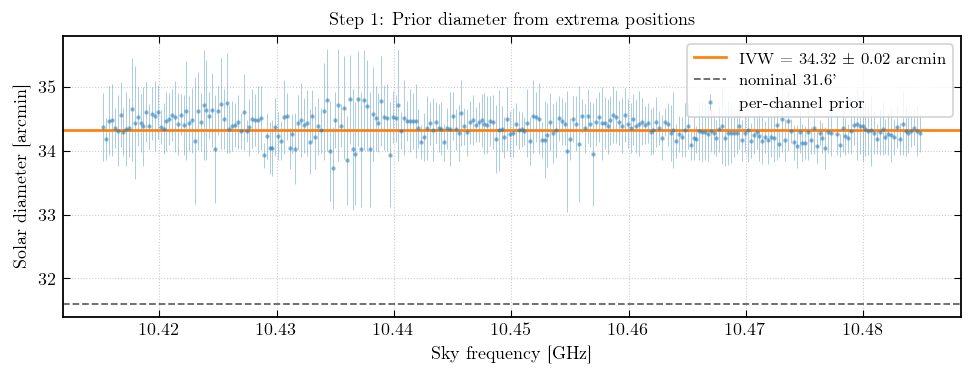

Exported R_prior to _R_prior_per_ch.pkl


In [9]:
# Compute R_prior for each good channel from window-matched features
R_prior_per_ch = {}
for k in all_ch:
    features = ch_extrema[k]
    if len(features) < 2:
        continue

    R_estimates = [f["root"] / (2 * np.pi * f["u"]) for f in features]

    R_prior_per_ch[k] = {
        "R_mean": float(np.mean(R_estimates)),
        "R_std": float(np.std(R_estimates, ddof=1)),
        "n": len(R_estimates),
    }

# ── IVW estimate across all channels ───────────────────────────────
prior_keys = sorted(R_prior_per_ch.keys())
prior_freqs = np.array([F_SKY_GHZ[k] for k in prior_keys])
prior_D = np.array([np.rad2deg(2 * R_prior_per_ch[k]["R_mean"]) * 60 for k in prior_keys])
prior_D_err = np.array([np.rad2deg(2 * R_prior_per_ch[k]["R_std"]) * 60 for k in prior_keys])

valid = prior_D_err > 0.01
w = 1.0 / prior_D_err[valid]**2
D_ivw = float(np.sum(w * prior_D[valid]) / np.sum(w))
D_ivw_err = float(1.0 / np.sqrt(np.sum(w)))
R_prior_ivw = np.deg2rad(D_ivw / 2.0 / 60.0)

print(f"Channels with valid R_prior: {valid.sum()} / {len(all_ch)}")
print(f"IVW prior diameter: {D_ivw:.3f} +/- {D_ivw_err:.3f} arcmin")
print(f"IVW prior radius:   {np.rad2deg(R_prior_ivw)*60:.3f} arcmin")

# ── Plot D_prior vs frequency ──────────────────────────────────────
fig, ax = plt.subplots(figsize=(TEXTWIDTH_IN, 3.0))
ax.errorbar(prior_freqs[valid], prior_D[valid], yerr=prior_D_err[valid],
            fmt=".", ms=3, color="C0", alpha=0.4, elinewidth=0.5, capsize=0,
            label="per-channel prior")
ax.axhline(D_ivw, color="C1", lw=LW_STANDARD,
           label=f"IVW = {D_ivw:.2f} $\pm$ {D_ivw_err:.2f} arcmin")
ax.axhline(SOLAR_DIAMETER_ARCMIN_NOMINAL, color="0.4", ls="--", lw=LW_LIGHT,
           label=f"nominal {SOLAR_DIAMETER_ARCMIN_NOMINAL}\'")
ax.set_xlabel("Sky frequency [GHz]")
ax.set_ylabel("Solar diameter [arcmin]")
ax.set_title("Step 1: Prior diameter from extrema positions", fontsize=TICK_SIZE)
ax.legend(fontsize=TICK_SIZE - 1)
fig.tight_layout()
plt.show()

# ── Export for downstream notebooks ────────────────────────────────
_r_prior_sidecar = Path("_R_prior_per_ch.pkl")
import pickle as _pkl
with open(_r_prior_sidecar, "wb") as _f:
    _pkl.dump({
        "R_prior_per_ch": R_prior_per_ch,
        "D_ivw": D_ivw,
        "D_ivw_err": D_ivw_err,
        "R_prior_ivw": R_prior_ivw,
    }, _f)
print(f"Exported R_prior to {_r_prior_sidecar}")

In [10]:
# Identify outlier channels with prior D < 33.9 arcmin
D_CUT = 33.9
outlier_keys = [k for k in prior_keys
                if np.rad2deg(2 * R_prior_per_ch[k]["R_mean"]) * 60 < D_CUT]
print(f"Outlier channels (D_prior < {D_CUT}\'): {len(outlier_keys)}")
for k in outlier_keys:
    D_k = np.rad2deg(2 * R_prior_per_ch[k]["R_mean"]) * 60
    print(f"  ch {k}: {F_SKY_GHZ[k]:.3f} GHz, D = {D_k:.2f}\'")

Outlier channels (D_prior < 33.9'): 2
  ch 593: 10.435 GHz, D = 33.73'
  ch 598: 10.436 GHz, D = 33.85'


## 6. Prior jinc envelope vs data

Plot the jinc envelope from $R_{\mathrm{prior}}$ (IVW) against the raw $|V|$ for the representative channel, with a fill-between band showing the $\pm 1\sigma$ range.

<>:49: SyntaxWarning: invalid escape sequence '\p'
<>:49: SyntaxWarning: invalid escape sequence '\p'
/tmp/ipykernel_801969/1676450430.py:49: SyntaxWarning: invalid escape sequence '\p'
  color="C1", alpha=0.2, label=f"$\pm${D_ivw_err:.2f}\' band")


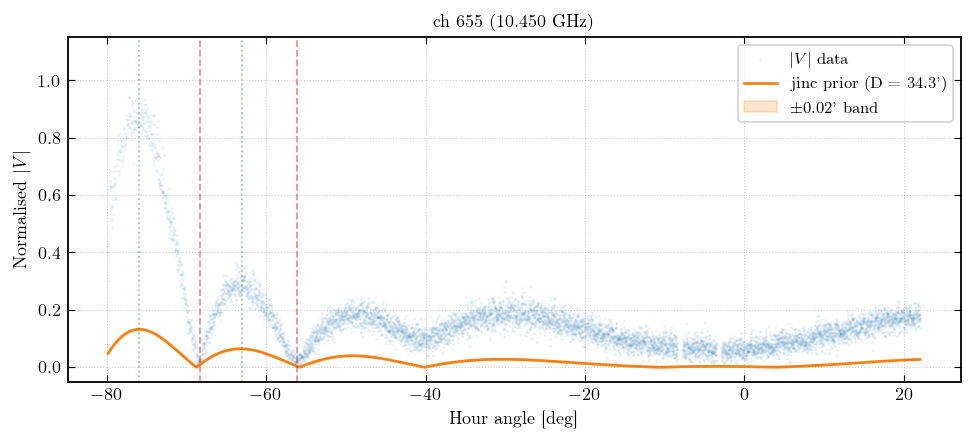

In [11]:
from scipy.special import j1 as J1

def jinc_envelope(q, A, R):
    """Uniform disk visibility: A * |2 J1(2 pi q R) / (2 pi q R)|."""
    x = 2 * np.pi * q * R
    out = np.ones_like(x, dtype=float)
    nz = x != 0
    out[nz] = np.abs(2 * J1(x[nz]) / x[nz])
    return A * out

k_show = k_mid
d = ch_data[k_show]

# Raw |V| and q for this channel
env_raw = np.abs(corr_dc[:, k_show])
q_raw = sky_baseline_lambda(ha_rad_arr, dec_rad_mean, B_EW, B_NS, float(F_SKY_HZ[k_show]))
finite = np.isfinite(env_raw) & np.isfinite(ha_deg_arr)

# Amplitude estimate: peak of raw data
A_est = float(np.nanmax(env_raw[finite]))

# Fine HA grid for smooth curves
ha_fine = d["ha_uni"]
q_fine  = d["u_uni"]

# IVW prior R and its error
R_center = R_prior_ivw
R_err = np.deg2rad(D_ivw_err / 2.0 / 60.0)

env_center = jinc_envelope(q_fine, A_est, R_center)
env_lo     = jinc_envelope(q_fine, A_est, R_center - R_err)
env_hi     = jinc_envelope(q_fine, A_est, R_center + R_err)
# Envelope of the two curves at each point (fill between min and max)
env_band_lo = np.minimum(env_lo, env_hi)
env_band_hi = np.maximum(env_lo, env_hi)

fig, ax = plt.subplots(figsize=(TEXTWIDTH_IN, 3.5))

# Raw data
ax.scatter(ha_deg_arr[finite], env_raw[finite] / A_est,
           s=0.3, alpha=0.08, color="C0", rasterized=True, label="$|V|$ data")

# Prior jinc
ax.plot(ha_fine, env_center / A_est, lw=LW_STANDARD, color="C1",
        label=f"jinc prior (D = {D_ivw:.1f}\')")

# Error band
ax.fill_between(ha_fine, env_band_lo / A_est, env_band_hi / A_est,
                color="C1", alpha=0.2, label=f"$\pm${D_ivw_err:.2f}\' band")

# Mark extrema
for f in ch_extrema[k_show]:
    if f["type"] == "min":
        ax.axvline(f["ha"], color="C3", lw=LW_LIGHT, ls="--", alpha=0.5)
    else:
        ax.axvline(f["ha"], color="C2", lw=LW_LIGHT, ls=":", alpha=0.5)

ax.set_xlabel("Hour angle [deg]")
ax.set_ylabel("Normalised $|V|$")
ax.set_title(f"ch {k_show} ({F_SKY_GHZ[k_show]:.3f} GHz)", fontsize=TICK_SIZE)
ax.legend(fontsize=TICK_SIZE - 1, loc="upper right")
ax.set_ylim(-0.05, 1.15)
fig.tight_layout()
plt.show()

Top 20 channels by |D_prior - D_ivw| (IVW = 34.32'):
  ch 593 (10.435 GHz): D = 33.73', delta = -0.59'
  ch 602 (10.437 GHz): D = 34.82', delta = +0.50'
  ch 599 (10.436 GHz): D = 34.80', delta = +0.49'
  ch 591 (10.434 GHz): D = 34.79', delta = +0.48'
  ch 604 (10.437 GHz): D = 34.79', delta = +0.48'
  ch 610 (10.439 GHz): D = 34.78', delta = +0.47'
  ch 598 (10.436 GHz): D = 33.85', delta = -0.46'
  ch 556 (10.426 GHz): D = 34.75', delta = +0.43'
  ch 554 (10.425 GHz): D = 34.74', delta = +0.42'
  ch 595 (10.435 GHz): D = 34.72', delta = +0.40'
  ch 548 (10.424 GHz): D = 34.71', delta = +0.40'
  ch 616 (10.440 GHz): D = 34.71', delta = +0.39'
  ch 569 (10.429 GHz): D = 33.93', delta = -0.39'
  ch 605 (10.438 GHz): D = 34.71', delta = +0.39'
  ch 613 (10.440 GHz): D = 33.94', delta = -0.38'
  ch 684 (10.457 GHz): D = 33.94', delta = -0.37'
  ch 601 (10.437 GHz): D = 33.95', delta = -0.37'
  ch 597 (10.436 GHz): D = 34.68', delta = +0.36'
  ch 523 (10.418 GHz): D = 34.65', delta = +0.3

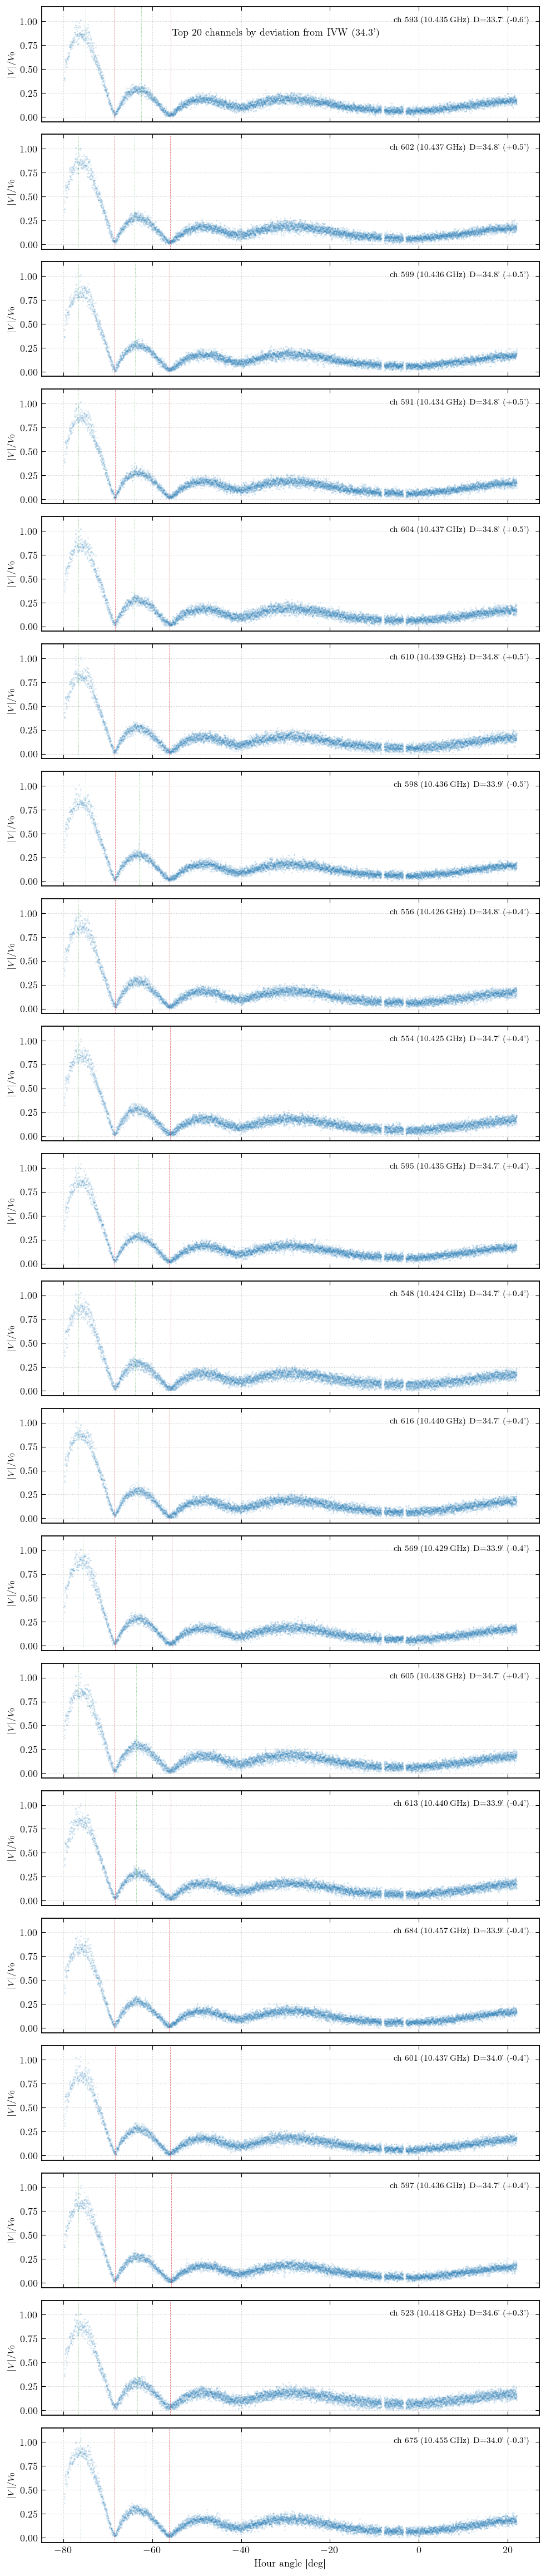

In [12]:
# 20 channels whose prior D deviates most from the IVW
N_SHOW = 20
deviation = np.abs(prior_D - D_ivw)
worst_idx = np.argsort(deviation[valid])[::-1][:N_SHOW]
worst_keys = [prior_keys[np.where(valid)[0][i]] for i in worst_idx]

print(f"Top {N_SHOW} channels by |D_prior - D_ivw| (IVW = {D_ivw:.2f}\'):")
for k in worst_keys:
    D_k = np.rad2deg(2 * R_prior_per_ch[k]["R_mean"]) * 60
    print(f"  ch {k} ({F_SKY_GHZ[k]:.3f} GHz): D = {D_k:.2f}\', delta = {D_k - D_ivw:+.2f}\'")

fig, axes = plt.subplots(N_SHOW, 1, figsize=(TEXTWIDTH_IN, 1.8 * N_SHOW),
                         sharex=True, sharey=True)

for i, k in enumerate(worst_keys):
    ax = axes[i]
    d = ch_data[k]
    env = d["env_raw"]
    finite = np.isfinite(ha_deg_arr) & np.isfinite(env)
    ax.scatter(ha_deg_arr[finite], env[finite] / d["V0"],
               s=0.3, alpha=0.15, color="C0", rasterized=True)

    for f in ch_extrema[k]:
        if f["type"] == "min":
            ax.axvline(f["ha"], color="C3", lw=0.5, ls="--", alpha=0.6)
        else:
            ax.axvline(f["ha"], color="C2", lw=0.5, ls=":", alpha=0.6)

    D_k = np.rad2deg(2 * R_prior_per_ch[k]["R_mean"]) * 60
    ax.set_ylabel("$|V|/V_0$", fontsize=TICK_SIZE - 1)
    ax.text(0.98, 0.92, f"ch {k} ({F_SKY_GHZ[k]:.3f} GHz)  D={D_k:.1f}\' ({D_k-D_ivw:+.1f}\')",
            transform=ax.transAxes, ha="right", va="top", fontsize=TICK_SIZE - 2)
    ax.set_ylim(-0.05, 1.15)

axes[-1].set_xlabel("Hour angle [deg]")
fig.suptitle(f"Top {N_SHOW} channels by deviation from IVW ({D_ivw:.1f}\')", fontsize=TICK_SIZE)
fig.tight_layout()
plt.show()